# 04 SHAP Analysis

## Purpose of SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to interpret how individual clinical features contribute to model predictions. This improves transparency and helps determine whether models rely on meaningful clinical variables, ensuring they align with medical domain knowledge.

The purpose of this notebook is to:
- Identify which clinical features influence model predictions.
- Compare feature importance between different ML models.
- Check whether models rely on meaningful clinical variables.
- Support the robustness analysis by analyzing how feature importance shifts under severe degradation conditions.

*Note: SHAP shows feature contribution to model predictions. It does not prove medical causation.*

**Important Methodology Note:**
This notebook trains each model on the complete pristine dataset to obtain stable feature importance estimates. The objective is model interpretation rather than estimating predictive performance. Model performance is evaluated separately in the baseline and robustness experiments.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.preprocessing import load_dataset
from src.models import get_models
from src.config import RANDOM_STATE, TIERS
from src.degradation import DataDegradationEngine
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create output directories if they don't exist
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("Loading pristine dataset...")
X, y, feature_names, lb, le, df = load_dataset()
X_df = pd.DataFrame(X, columns=feature_names)
print(f"Dataset loaded successfully with {X_df.shape[0]} samples and {X_df.shape[1]} features.")


Loading pristine dataset...
[SUCCESS] Loaded Dataset: 1014 records[cite: 1].
Dataset loaded successfully with 1014 samples and 6 features.


In [3]:
print("Training baseline models...")
models = get_models(random_state=RANDOM_STATE)

for name, model in models.items():
    model.fit(X_df, y)
    print(f"✅ {name} trained.")


Training baseline models...
✅ Logistic Regression trained.
✅ Random Forest trained.
✅ Support Vector Machine trained.
✅ XGBoost trained.


In [4]:
def get_mean_abs_shap(shap_values):
    # Depending on the model and explainer, shap_values might be a list (multiclass) or array
    if isinstance(shap_values, list):
        class_means = [np.abs(sv).mean(axis=0) for sv in shap_values]
        return np.mean(class_means, axis=0)
    elif hasattr(shap_values, "values"):
        vals = shap_values.values
        if len(vals.shape) == 3:
            return np.abs(vals).mean(axis=(0, 2))
        return np.abs(vals).mean(axis=0)
    else:
        if len(shap_values.shape) == 3:
            return np.abs(shap_values).mean(axis=(0, 2))
        return np.abs(shap_values).mean(axis=0)

shap_feature_importances = []
def record_shap_importance(model_name, mean_abs_shap, feature_names):
    for idx, feature in enumerate(feature_names):
        shap_feature_importances.append({
            "Model": model_name,
            "Feature": feature,
            "Mean SHAP Value": mean_abs_shap[idx]
        })


Background dataset has 1014 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1014 when initializing the masker.


Computing SHAP values and generating plots...

Explaining Logistic Regression...


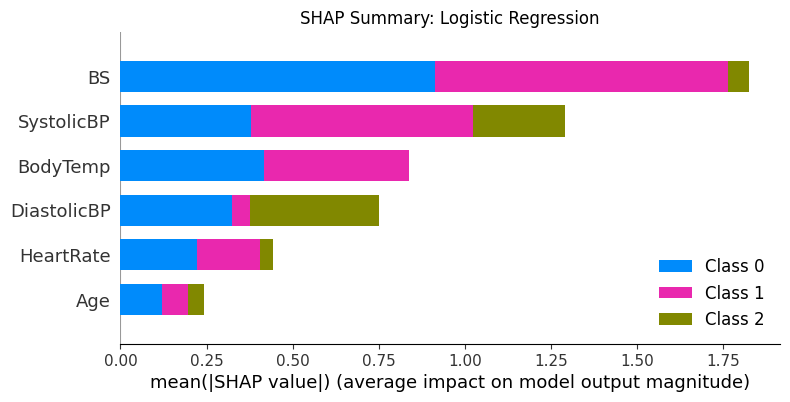


Explaining Random Forest...


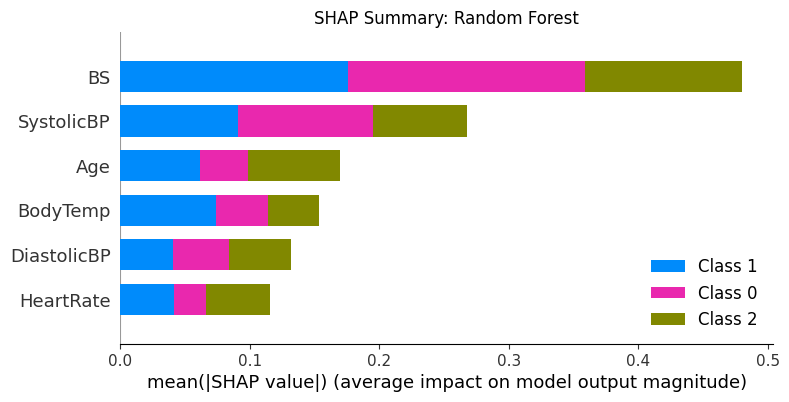


Explaining Support Vector Machine...


100%|██████████| 100/100 [00:05<00:00, 19.41it/s]


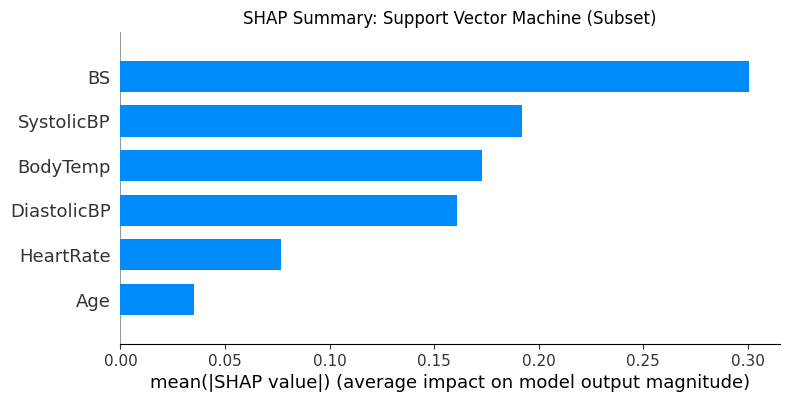


Explaining XGBoost...


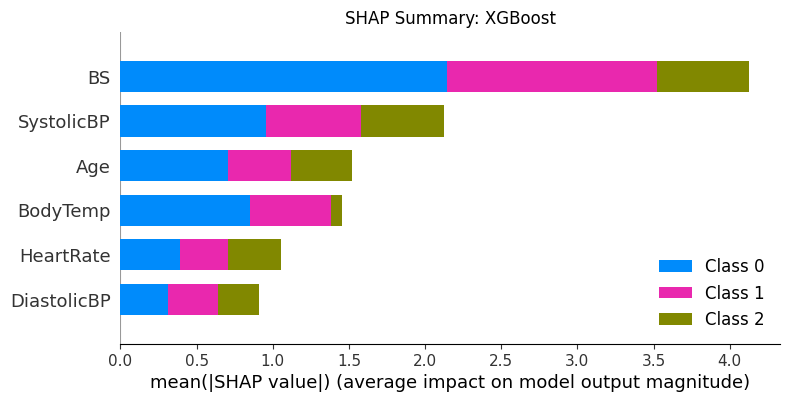

In [5]:
print("Computing SHAP values and generating plots...")

for name, model in models.items():
    print(f"\nExplaining {name}...")
    plt.figure()
    
    if name == "Random Forest" or name == "XGBoost":
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_df)
        
        mean_abs_shap = get_mean_abs_shap(shap_values)
        
        shap.summary_plot(shap_values, X_df, plot_type="bar", show=False)
        plt.title(f"SHAP Summary: {name}")
        plt.savefig(f"../results/figures/shap_{name.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
        if name == "Random Forest":
            plt.savefig(f"../results/figures/shap_random_forest_pristine.png", dpi=300, bbox_inches="tight")
        plt.show()
        record_shap_importance(name, mean_abs_shap, feature_names)

    elif name == "Logistic Regression":
        scaler = model.named_steps['scaler']
        lr_model = model.named_steps['lr']
        X_scaled = pd.DataFrame(scaler.transform(X_df), columns=feature_names)
        
        explainer = shap.LinearExplainer(lr_model, X_scaled)
        shap_values = explainer.shap_values(X_scaled)
        
        mean_abs_shap = get_mean_abs_shap(shap_values)
        
        shap.summary_plot(shap_values, X_scaled, plot_type="bar", show=False)
        plt.title(f"SHAP Summary: {name}")
        plt.savefig(f"../results/figures/shap_logistic_regression.png", dpi=300, bbox_inches="tight")
        plt.show()
        record_shap_importance(name, mean_abs_shap, feature_names)

    elif name == "Support Vector Machine":
        scaler = model.named_steps['scaler']
        svm_model = model.named_steps['svm']
        X_scaled = pd.DataFrame(scaler.transform(X_df), columns=feature_names)
        
        background = shap.kmeans(X_scaled, 10)
        explainer = shap.KernelExplainer(svm_model.predict, background)
        
        subset_X = X_scaled.sample(n=min(100, len(X_scaled)), random_state=RANDOM_STATE)
        shap_values = explainer.shap_values(subset_X)
        
        mean_abs_shap = get_mean_abs_shap(shap_values)
        
        shap.summary_plot(shap_values, subset_X, plot_type="bar", show=False)
        plt.title(f"SHAP Summary: {name} (Subset)")
        plt.savefig(f"../results/figures/shap_svm.png", dpi=300, bbox_inches="tight")
        plt.show()
        record_shap_importance(name, mean_abs_shap, feature_names)


In [6]:
importance_df = pd.DataFrame(shap_feature_importances)

# Calculate Rankings
importance_df["Rank"] = importance_df.groupby("Model")["Mean SHAP Value"].rank(ascending=False, method='min').astype(int)
importance_df = importance_df.sort_values(by=["Model", "Rank"])

importance_df.to_csv("../results/tables/shap_feature_importance.csv", index=False)
importance_df.to_csv("../results/tables/shap_feature_ranking.csv", index=False)

print("Saved SHAP feature importance to results/tables/shap_feature_importance.csv")
print("Saved SHAP feature ranking to results/tables/shap_feature_ranking.csv")

importance_df


Saved SHAP feature importance to results/tables/shap_feature_importance.csv
Saved SHAP feature ranking to results/tables/shap_feature_ranking.csv


,Model,Feature,Mean SHAP Value,Rank
3,Logistic Regression,BS,0.607802,1
1,Logistic Regression,SystolicBP,0.429925,2
4,Logistic Regression,BodyTemp,0.279493,3
2,Logistic Regression,DiastolicBP,0.250175,4
5,Logistic Regression,HeartRate,0.147553,5
0,Logistic Regression,Age,0.080827,6
9,Random Forest,BS,0.159959,1
7,Random Forest,SystolicBP,0.089329,2
6,Random Forest,Age,0.056421,3
10,Random Forest,BodyTemp,0.051222,4


## Interpretation of SHAP Results

After running the analysis, discuss:
- the most influential features
- whether BP and BS dominate the models
- differences between linear and tree-based models
- whether the rankings align with clinical knowledge

## Robustness SHAP Comparison: Pristine vs Tier 3 (Severe)

To understand whether feature importance changes when data quality decreases, we compare the Random Forest SHAP values between the clean dataset and the Tier 3 severe degradation dataset. Under severe degradation, noisy BP measurements, temperature bias, and missing values may force the model to alter its feature dependence.

Generating Tier 3 Degraded Dataset for SHAP comparison...
Explaining Random Forest on Tier 3 Degraded Data...


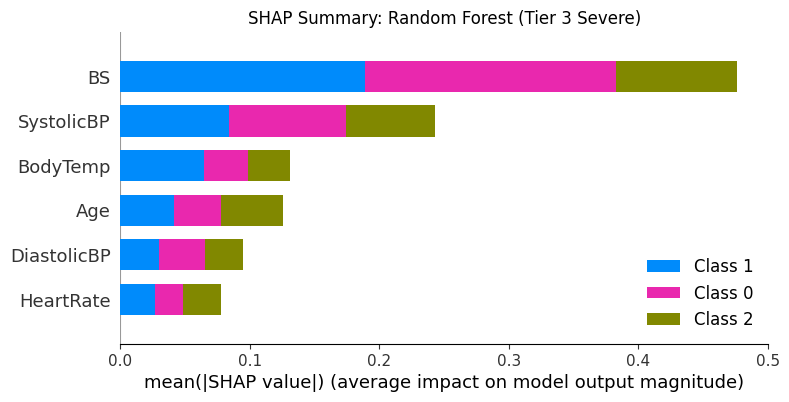


Pristine Top 5:
1. BS
2. SystolicBP
3. Age
4. BodyTemp
5. DiastolicBP

Tier 3 Top 5:
1. BS
2. SystolicBP
3. BodyTemp
4. Age
5. DiastolicBP

Tier 3 SHAP analysis completed.
Figure saved to: results/figures/shap_random_forest_tier3.png


In [7]:
print("Generating Tier 3 Degraded Dataset for SHAP comparison...")
engine = DataDegradationEngine(random_state=RANDOM_STATE)

X_tier3_corrupted = engine.apply_degradation(X_df, TIERS["Tier 3 (Severe)"])

mice_imputer = IterativeImputer(random_state=RANDOM_STATE, max_iter=10)
mice_imputer.fit(X_df)

X_tier3_defended = pd.DataFrame(mice_imputer.transform(X_tier3_corrupted), columns=feature_names)

print("Explaining Random Forest on Tier 3 Degraded Data...")
rf_model = models["Random Forest"]
rf_explainer = shap.TreeExplainer(rf_model)
shap_values_tier3 = rf_explainer.shap_values(X_tier3_defended)

plt.figure()
shap.summary_plot(shap_values_tier3, X_tier3_defended, plot_type="bar", show=False)
plt.title("SHAP Summary: Random Forest (Tier 3 Severe)")
plt.savefig(f"../results/figures/shap_random_forest_tier3.png", dpi=300, bbox_inches="tight")
plt.show()

# Compute differences in top 5 features
mean_abs_shap_tier3 = get_mean_abs_shap(shap_values_tier3)
tier3_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean SHAP Value": mean_abs_shap_tier3
})
tier3_df["Rank"] = tier3_df["Mean SHAP Value"].rank(ascending=False, method='min').astype(int)
tier3_df = tier3_df.sort_values(by="Rank")

pristine_rf = importance_df[importance_df["Model"] == "Random Forest"].sort_values(by="Rank")

print("\nPristine Top 5:")
for idx, row in pristine_rf.head(5).iterrows():
    print(f"{row['Rank']}. {row['Feature']}")

print("\nTier 3 Top 5:")
for idx, row in tier3_df.head(5).iterrows():
    print(f"{row['Rank']}. {row['Feature']}")

print("\nTier 3 SHAP analysis completed.")
print("Figure saved to: results/figures/shap_random_forest_tier3.png")
